**Función de utilidad para mostrar la neurona**

In [4]:
def visualizar_neurona(entradas, pesos, bias, activacion=sigmoid, nombre_activacion="sigmoid"):
    entradas = np.array(entradas, dtype=float)
    pesos = np.array(pesos, dtype=float)

    contribuciones = entradas * pesos
    z = np.sum(contribuciones) + bias
    a = activacion(z)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Entradas
    axes[0].bar(range(len(entradas)), entradas)
    axes[0].set_title("Entradas")
    axes[0].set_xlabel("Entrada")
    axes[0].set_ylabel("Valor")
    axes[0].set_xticks(range(len(entradas)))
    axes[0].set_xticklabels([f"x{i+1}" for i in range(len(entradas))])
    axes[0].grid(True, axis="y")

    # Entradas * pesos + bias
    etiquetas = [f"x{i+1}·w{i+1}" for i in range(len(entradas))] + ["bias"]
    valores = list(contribuciones) + [bias]
    axes[1].bar(etiquetas, valores)
    axes[1].axhline(0, linewidth=1)
    axes[1].set_title(f"Suma ponderada: z = {z:.3f}")
    axes[1].grid(True, axis="y")

    # Activación
    xs = np.linspace(-6, 6, 400)
    ys = activacion(xs)
    axes[2].plot(xs, ys)
    axes[2].scatter([z], [a], s=80)
    axes[2].axvline(z, linestyle="--")
    axes[2].set_title(f"Salida: {nombre_activacion}(z) = {a:.3f}")
    axes[2].set_xlabel("z")
    axes[2].set_ylabel("a")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

    print("entradas =", entradas)
    print("pesos =", pesos)
    print("bias =", bias)
    print("entradas * pesos =", contribuciones)
    print("z =", z)
    print("salida =", a)

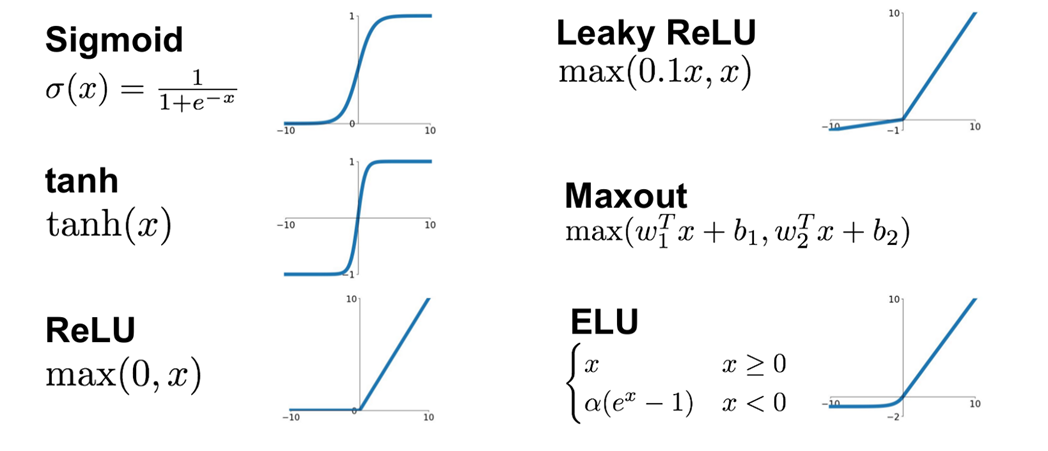


**Fuente:** *https://navdeepdhakar.hashnode.dev/simplified-approach-to-deep-learning*

In [3]:
import numpy as np
import matplotlib.pyplot as plt

**Funciones de activación**

In [5]:
def sigmoid(x):
    return 1/(1+np.exp(-1*x))

def relu(x):
    return np.maximum(0, x)

def linear (x):
    return x

def binary_step(x):
    return 1 if x > 0 else 0



**Neurona artificial**

In [6]:
def neurona(entradas, pesos, bias, activacion):
    entradas = np.array(entradas, dtype =float)
    pesos = np.array(pesos, dtype=float)

    z = np.sum(entradas*pesos) + bias
    a = activacion(z)

    return a

**Probamos la neurona**


Entradas: [0.8, -0.4]
Pesos: [1.2, -0.7]
Bias: 0.3
Salida = 0.8234647252208833


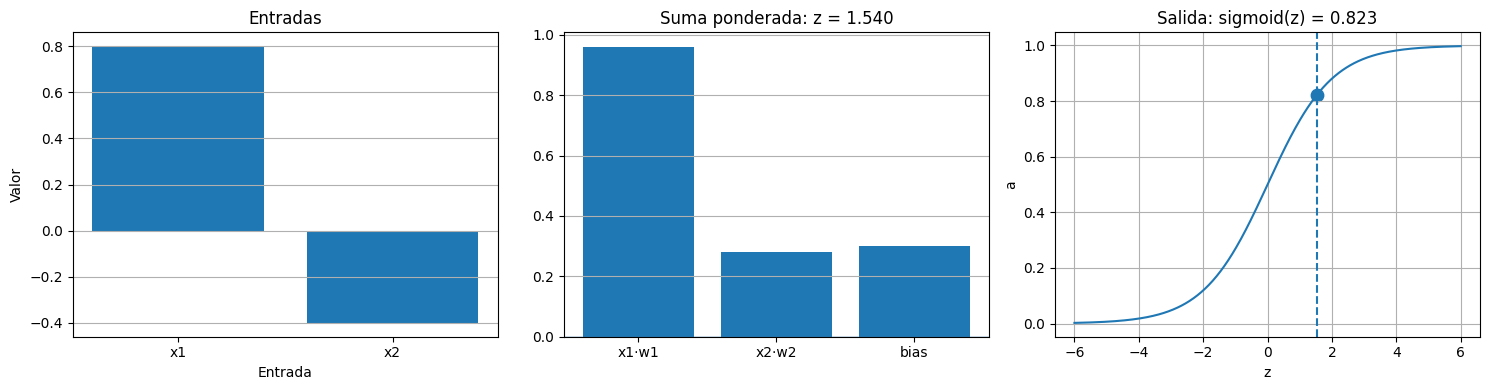

entradas = [ 0.8 -0.4]
pesos = [ 1.2 -0.7]
bias = 0.3
entradas * pesos = [0.96 0.28]
z = 1.54
salida = 0.8234647252208833


In [8]:
entradas = [0.8, -0.4]
pesos = [1.2, -0.7]
bias = 0.3

salida = neurona(entradas, pesos, bias, activacion=sigmoid)

print("Entradas:", entradas)
print("Pesos:", pesos)
print("Bias:", bias)
print("Salida =", salida)


visualizar_neurona(entradas, pesos, bias, sigmoid, "sigmoid")

**Capa**

In [15]:
def capas(entradas, neuronas):
    salidas=[]

    for i, n in enumerate(neuronas):
        salida = neurona(entradas=entradas,
                         pesos=n["pesos"],
                         bias=n["bias"],
                         activacion=n["activacion"]
                        )
        salidas.append(salida)
    return salidas

**Red neuronal**

In [16]:
def red_neuronal(entradas, red):
    historial = []
    for i, capa_actual in enumerate(red):
        salidas = capas(entradas, capa_actual)

        historial.append({
            f"capas {i}" : i,
            "entradas" : entradas,
            "salidas" : salidas
        })

        entradas = salidas
    
    return entradas, historial

**Probamos y ejecutamos la red**:

Red de ejemplo con parámetros definidos por nosotros a mano

In [17]:
red = [
    [
        {
            "pesos": [0.5, -0.2],
            "bias": 0.1,
            "activacion": relu
        },
        {
            "pesos": [0.8, 0.4],
            "bias": -0.3,
            "activacion": relu
        },
        {
            "pesos": [-0.6, 0.9],
            "bias": 0.2,
            "activacion": relu
        }
    ],
    [
        {
            "pesos": [1.0, -1.2, 0.7],
            "bias": 0.05,
            "activacion": sigmoid
        }
    ]
]


#DATOS ENTRADA
x = [0.7, -0.5]

In [18]:
salida, historial = red_neuronal(x, red)

print("Salida final", salida)


Salida final [np.float64(0.6290165230447227)]


**KERAS**

https://keras.io/api/

In [20]:
import numpy as np
import keras
import os
import torch
import torch.nn as nn
os.environ["KERAS_BACKEND"] = "torch"

x = np.array([[0.7, -0.5]], dtype=np.float32)

pesos_ocultas = np.array([
    [ 0.5,  0.8, -0.6],
    [-0.2,  0.4,  0.9]
], dtype=np.float32)
bias_ocultas = np.array([0.1, -0.3, 0.2], dtype=np.float32)

pesos_salida = np.array([
    [ 1.0],
    [-1.2],
    [ 0.7]
], dtype=np.float32)
bias_salida = np.array([0.05], dtype=np.float32)


ModuleNotFoundError: No module named 'torch'

In [21]:
modelo = nn.Sequential(
    nn.Linear(2,3),
    nn.Relu(),
    nn.Linear(3,1),
    nn.Sigmoid()
)

with torch.no_grad():
    modelo[0].weight[:] = pesos_ocultas
    modelo[0].weight[:] = bias_ocultas

    modelo[2].weight[:] = pesos_salida
    modelo[2].weight[:] = bias_salida

y= modelo(x)

print(y.item())
    

NameError: name 'nn' is not defined

**PYTORCH**

https://docs.pytorch.org/docs/stable/index.html

In [ ]:
import torch
import torch.nn as nn

x = torch.tensor([[0.7, -0.5]], dtype=torch.float32)
pesos_ocultas = torch.tensor([
        [ 0.5, -0.2],
        [ 0.8,  0.4],
        [-0.6,  0.9]
    ])

pesos_salida = torch.tensor([[1.0, -1.2, 0.7]])

bias_ocultas = torch.tensor([0.1, -0.3, 0.2])
bias_salida = torch.tensor([0.05])